# FUTS: Flat UCB Tree Search Experiment Pipeline

This notebook demonstrates the FUTS (Flat UCB Tree Search) algorithm applied to the California Housing dataset (Kaggle Playground Series S3E1).

The pipeline involves:
1. **Data Preparation**: Loading the housing data and creating a local validation split.
2. **Search Experiment**: Running the FUTS algorithm to find an improved machine learning model.
3. **Visualization**: Plotting the improvement in model performance (RMSE) over iterations.

### Prerequisites

* You need to define a desired version of llm.py, which contains your desired LLM. To give an example, the current implementation is defined for Gemini.
* You need an API Key for the LLM.


In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.metrics import mean_squared_error

# Add current directory to path for local imports
sys.path.append(os.getcwd())

import futs
from sandbox import ExecSandbox
from llm import GeminiLLM

# SET YOUR API KEY HERE
os.environ["GEMINI_API_KEY"] = "PUT_API_KEY_HERE"

api_key = os.environ.get("GEMINI_API_KEY")
if not api_key or api_key == "YOUR_API_KEY":
    print("WARNING: GEMINI_API_KEY not set. The search will fail.")
else:
    print("Gemini API Key found.")


Gemini API Key found.


## 1. Data Preparation

We use the California Housing dataset. The raw data is unzipped into `data/playground-series-s3e1/`.
We provide a local validation split to evaluate the generated models.


In [6]:
from playground_s3e1 import prepare_data, DATA_DIR, TRAIN_PATH, TEST_PATH, get_data_head

# Ensure data directory exists and is prepared
if not os.path.exists(TRAIN_PATH):
    print("Preparing data...")
    y_true = prepare_data()
else:
    print("Data already prepared.")
    y_true = pd.read_csv(os.path.join(DATA_DIR, "local_test_with_target.csv"))['MedHouseVal'].values if os.path.exists(os.path.join(DATA_DIR, "local_test_with_target.csv")) else None
    if y_true is None:
         # Fallback split
         df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
         train_size = int(0.8 * len(df))
         y_true = df.iloc[train_size:]['MedHouseVal'].values

print(f"Validation set size: {len(y_true)}")
print("\nData Preview:")
print(pd.read_csv(TRAIN_PATH).head())


Data already prepared.
Validation set size: 7428

Data Preview:
   id  MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0   0  2.3859      15.0  3.827160   1.112100      1280.0  2.486989     34.60   
1   1  3.7188      17.0  6.013373   1.054217      1504.0  3.813084     38.69   
2   2  4.7750      27.0  6.535604   1.103175      1061.0  2.464602     34.71   
3   3  2.4138      16.0  3.350203   0.965432      1255.0  2.089286     32.66   
4   4  3.7500      52.0  4.284404   1.069246      1793.0  1.604790     37.80   

   Longitude  MedHouseVal  
0    -120.12        0.980  
1    -121.22        0.946  
2    -120.45        1.576  
3    -117.09        1.336  
4    -122.41        4.500  


## 2. Search Experiment

We'll run the search process. We define a `TrackingExecutor` to keep track of the best score found at each iteration.


In [7]:
from playground_s3e1 import PlaygroundProblem, PlaygroundGenerator, PlaygroundExecutor

def run_notebook_experiment(iterations=10):
    if not api_key:
        print("Set GEMINI_API_KEY to run.")
        return [], None, None

    llm = GeminiLLM(api_key)
    sandbox = ExecSandbox(timeout_seconds=60)
    problem = PlaygroundProblem("Improve the regression model for the California Housing dataset.")
    
    # Initial naive solution
    initial_code = """
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

def train_and_predict(train_path, test_path):
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    X = train.drop('MedHouseVal', axis=1)
    y = train['MedHouseVal']
    model = LinearRegression()
    model.fit(X, y)
    return model.predict(test)
"""
    initial_solution = futs.Solution(initial_code)
    executor = PlaygroundExecutor(sandbox, y_true)
    
    print("Evaluating initial solution...")
    initial_score = executor(problem, initial_solution)
    print(f"Initial Score (Neg RMSE): {initial_score:.4f}")
    
    generator = PlaygroundGenerator(llm)
    history = []
    
    class TrackingExecutor:
        def __init__(self, inner_executor):
            self.inner = inner_executor
            self.best_so_far = initial_score
            self.iteration = 0
            
        def __call__(self, problem, solution):
            score = self.inner(problem, solution)
            self.iteration += 1
            if score > self.best_so_far:
                self.best_so_far = score
                print(f"Iteration {self.iteration}: New Best Score! {score:.4f}")
            else:
                print(f"Iteration {self.iteration}: Score {score:.4f} (Best: {self.best_so_far:.4f})")
            history.append({"iteration": self.iteration, "best_score": self.best_so_far, "current_score": score})
            return score

    tracking_executor = TrackingExecutor(executor)
    history.append({"iteration": 0, "best_score": initial_score, "current_score": initial_score})

    print(f"\nStarting Search ({iterations} iterations)...")
    best_sol, best_score = futs.search(
        problem=problem,
        initial_solution=initial_solution,
        initial_score=initial_score,
        generate_fn=generator,
        execute_fn=tracking_executor,
        num_iterations=iterations,
        c_puct=1.0 
    )
    
    return history, best_sol, best_score

# Run a small experiment
history, best_sol, best_score = run_notebook_experiment(iterations=5)


Evaluating initial solution...
Initial Score (Neg RMSE): -0.7339

Starting Search (5 iterations)...
Iteration 1: New Best Score! -0.6122
Iteration 2: New Best Score! -0.5967
Iteration 3: New Best Score! -0.5869
Iteration 4: Score -0.5883 (Best: -0.5869)
Execution failed: EXECUTION_ERROR: Cannot set a DataFrame with multiple columns to the single column Lat_Plus_Lon
Iteration 5: Score -inf (Best: -0.5869)


## 3. Visualization

Finally, we plot the search progress.


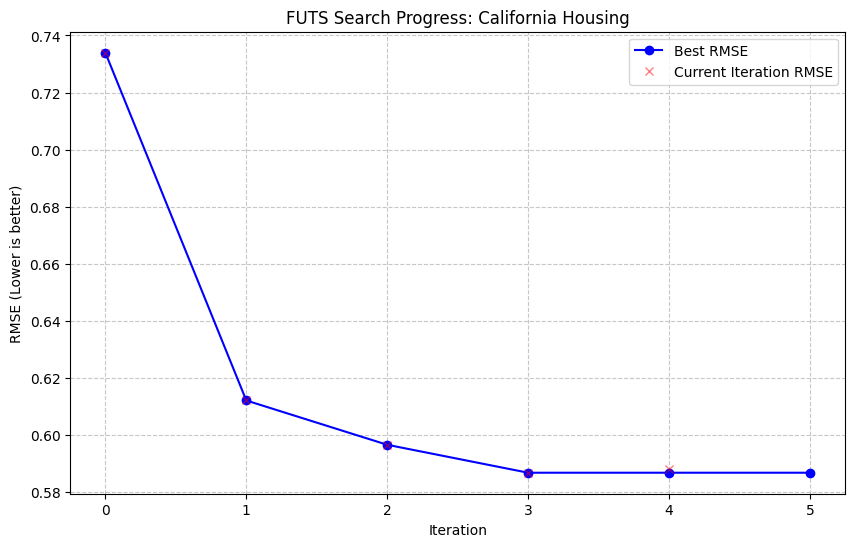


Final Best Score (Neg RMSE): -0.5869

Best Solution Code:
----------------------------------------
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

def train_and_predict(train_path, test_path):
    # Load data
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    
    # Drop 'id' column as it's not a feature
    train = train.drop('id', axis=1)
    test_ids = test['id'] 
    test = test.drop('id', axis=1)
    
    # Define features (X) and target (y)
    X_train = train.drop('MedHouseVal', axis=1)
    y_train = train['MedHouseVal']
    X_test = test.copy()
    
    # Feature Engineering
    X_train['RoomsPerPerson'] = X_train['AveRooms'] / X_train['AveOccup']
    X_tes

In [8]:
if history:
    df_history = pd.DataFrame(history)
    
    plt.figure(figsize=(10, 6))
    plt.plot(df_history['iteration'], -df_history['best_score'], marker='o', linestyle='-', color='b', label='Best RMSE')
    plt.plot(df_history['iteration'], -df_history['current_score'], marker='x', linestyle='', color='r', alpha=0.5, label='Current Iteration RMSE')
    
    plt.title('FUTS Search Progress: California Housing')
    plt.xlabel('Iteration')
    plt.ylabel('RMSE (Lower is better)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

    print(f"\nFinal Best Score (Neg RMSE): {best_score:.4f}")
    print("\nBest Solution Code:")
    print("-" * 40)
    print(best_sol.program)
    print("-" * 40)
